Energy: 0.7071067811865475


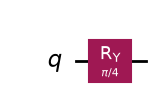

In [8]:
# part 4 - VQE - Variational Quantum Eigensolver
# Find lowest eigenvalue of a Hamiltonian, uses both quantum and classical methods
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
import numpy as np

# Hamiltonian: H = Z
hamiltonian = SparsePauliOp.from_list([("Z", 1.0)])

# Ansatz: Ry(theta)|0>
theta = np.pi
#theta = np.pi/4 mess with the theta for practice, our resulting energy corresponds to cos(theta)
qc = QuantumCircuit(1)
qc.ry(theta, 0)

state = Statevector.from_instruction(qc)
energy = state.expectation_value(hamiltonian).real

print("Energy:", energy)
display(qc.draw(output="mpl", style="iqp"))

Number of parameters: 8


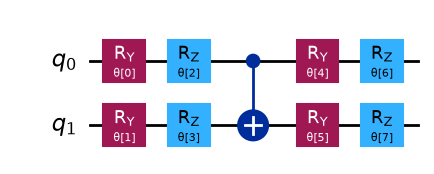

In [5]:
from qiskit.circuit.library import efficient_su2

ansatz = efficient_su2(
    num_qubits=2,
    reps=1,
    entanglement="linear"
)

print("Number of parameters:", ansatz.num_parameters)
display(ansatz.draw(output="mpl", style="iqp"))

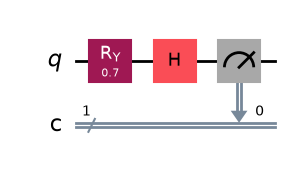

In [6]:
from qiskit import QuantumCircuit

# Basis rotation for measuring X on a single qubit
qc = QuantumCircuit(1, 1)
qc.ry(0.7, 0)
qc.h(0)          # Rotate X basis into Z basis
qc.measure(0, 0)

display(qc.draw(output="mpl", style="iqp"))

Optimal energy: -2.2360679732137267
Optimal parameters:
[1.039749   6.11662988 2.90506451 4.70518341 5.64200023 3.20461765
 3.0778314  0.51576126 1.64688457 4.53925055 5.45944067 6.10324267
 2.18740451 1.32019883 2.97091347 5.52800946]
Exact ground-state energy: -2.23606797749979
Absolute error: 4.286063060021661e-09
Number of evaluations: 184


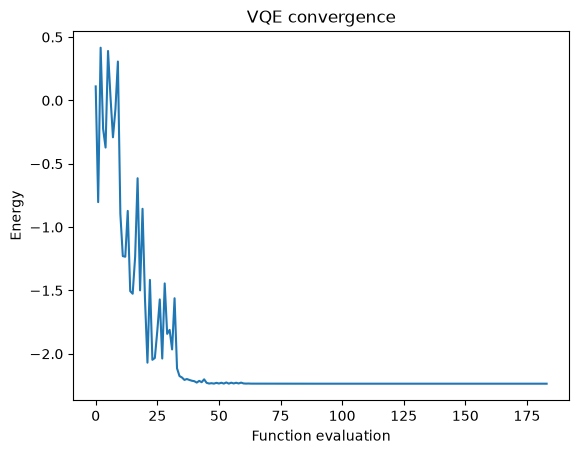

In [14]:
# If needed:
# !pip install qiskit scipy numpy matplotlib

import numpy as np
from scipy.optimize import minimize
from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

energy_history = [] # added for practice

# --------------------------------------------------
# 1. Define the Hamiltonian
# --------------------------------------------------

hamiltonian = SparsePauliOp.from_list([
    ("ZI", 1.0),
    ("IZ", 1.0),
    #("XX", 0.5)
    ("XX", 1.0) #practice task: running this gives a lower energy and seems to give more error
])

# --------------------------------------------------
# 2. Build a parameterized ansatz
# --------------------------------------------------

ansatz = efficient_su2(
    num_qubits=2,
    reps=3, # reps upped from 1, increases accuracy (lower error val)
    entanglement="linear"
)

estimator = StatevectorEstimator()

# --------------------------------------------------
# 3. Define the VQE cost function
# --------------------------------------------------

def cost_function(params):
    # An Estimator PUB has the form:
    # (circuit, observable, parameter_values)
    pub = (ansatz, hamiltonian, [params])
    result = estimator.run([pub]).result()[0]

    # result.data.evs is array-like, even for one parameter set.
    energy = np.asarray(result.data.evs).reshape(-1)[0]
    energy_history.append(energy)
    return float(energy)

# --------------------------------------------------
# 4. Run the classical optimizer
# --------------------------------------------------

np.random.seed(7)
initial_params = 2 * np.pi * np.random.random(ansatz.num_parameters)

result = minimize(
    cost_function,
    initial_params,
    method="COBYLA",
    options={"maxiter": 200}
)

# --------------------------------------------------
# 5. Display the result
# --------------------------------------------------

print("Optimal energy:", result.fun)
print("Optimal parameters:")
print(result.x)

# --------------------------------------------------
# 6. Compare against exact diagonalization
# --------------------------------------------------

exact_energies = np.linalg.eigvalsh(hamiltonian.to_matrix())
exact_ground_energy = np.min(exact_energies)

print("Exact ground-state energy:", exact_ground_energy)
print("Absolute error:", abs(result.fun - exact_ground_energy))\

# added from practice section
print("Number of evaluations:", len(energy_history))

import matplotlib.pyplot as plt

plt.plot(energy_history)
plt.xlabel("Function evaluation")
plt.ylabel("Energy")
plt.title("VQE convergence")
plt.show()

Final energy: -2.0612364026431833
Number of evaluations: 100


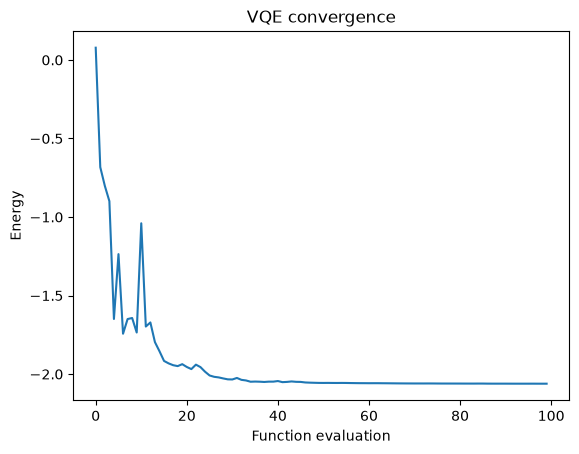

In [10]:
energy_history = []

def tracked_cost_function(params):
    pub = (ansatz, hamiltonian, [params])
    result = estimator.run([pub]).result()[0]
    energy = float(np.asarray(result.data.evs).reshape(-1)[0])
    energy_history.append(energy)
    return energy

np.random.seed(10)
initial_params = 2 * np.pi * np.random.random(ansatz.num_parameters)

tracked_result = minimize(
    tracked_cost_function,
    initial_params,
    method="COBYLA",
    options={"maxiter": 100}
)

print("Final energy:", tracked_result.fun)
print("Number of evaluations:", len(energy_history))

import matplotlib.pyplot as plt

plt.plot(energy_history)
plt.xlabel("Function evaluation")
plt.ylabel("Energy")
plt.title("VQE convergence")
plt.show()

In [1]:
# If needed:
# !pip install qiskit qiskit-algorithms scipy numpy

import numpy as np
from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import COBYLA

hamiltonian = SparsePauliOp.from_list([
    ("ZI", 1.0),
    ("IZ", 1.0),
    ("XX", 0.5)
])

ansatz = efficient_su2(2, reps=1, entanglement="linear")
estimator = StatevectorEstimator()
optimizer = COBYLA(maxiter=200)

np.random.seed(7)
initial_point = 2 * np.pi * np.random.random(ansatz.num_parameters)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    initial_point=initial_point
)

result = vqe.compute_minimum_eigenvalue(hamiltonian)

print("Estimated ground-state energy:", result.eigenvalue.real)
print("Optimal parameters:", result.optimal_point)

Estimated ground-state energy: -2.0615429487662262
Optimal parameters: [ 2.4847117   4.3045526   3.14335351  6.27848377  6.89904059  4.38111838
  3.19588405 -0.07163883]


In [4]:
# I would run the hardware ver, but I cannot run sessions on the IBM free plan